In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import math
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


# 프로젝트: 한국어 데이터로 챗봇 만들기

영어로 만들었던 챗봇을 한국어 데이터로 바꿔서 훈련시켜봅시다.

## Step 1. 데이터 수집하기
---
한국어 챗봇 데이터는 송영숙님이 공개한 챗봇 데이터를 사용합니다.

- [songys/Chatbot_data](https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv)

In [3]:
# 한국어 챗봇 데이터 로드
data_path = '/Users/robotjang/Downloads/pytorchtrf-main/Ex08/data/ChatbotData.csv'
df = pd.read_csv(data_path)

print('데이터 샘플 수:', len(df))
print('컬럼:', df.columns.tolist())
print('\n데이터 예시:')
print(df.head(10))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/robotjang/Downloads/pytorchtrf-main/Ex08/data/ChatbotData.csv'

In [4]:
import requests

# URL of the dataset on GitHub
url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'

# Define the local filename to save the data
local_filename = 'ChatbotData.csv'

# Download the file
response = requests.get(url)
response.raise_for_status()  # Raise an exception for HTTP errors

with open(local_filename, 'wb') as f:
    f.write(response.content)

print(f'Successfully downloaded {local_filename}')

# Update the data_path to use the locally downloaded file
data_path = local_filename

Successfully downloaded ChatbotData.csv


In [5]:
# 한국어 챗봇 데이터 로드
df = pd.read_csv(data_path)

print('데이터 샘플 수:', len(df))
print('컬럼:', df.columns.tolist())
print('\n데이터 예시:')
print(df.head(10))

데이터 샘플 수: 11823
컬럼: ['Q', 'A', 'label']

데이터 예시:
                         Q                   A  label
0                   12시 땡!          하루가 또 가네요.      0
1              1지망 학교 떨어졌어           위로해 드립니다.      0
2             3박4일 놀러가고 싶다         여행은 언제나 좋죠.      0
3          3박4일 정도 놀러가고 싶다         여행은 언제나 좋죠.      0
4                  PPL 심하네          눈살이 찌푸려지죠.      0
5                SD카드 망가졌어  다시 새로 사는 게 마음 편해요.      0
6                  SD카드 안돼  다시 새로 사는 게 마음 편해요.      0
7           SNS 맞팔 왜 안하지ㅠㅠ    잘 모르고 있을 수도 있어요.      0
8  SNS 시간낭비인 거 아는데 매일 하는 중       시간을 정하고 해보세요.      0
9        SNS 시간낭비인데 자꾸 보게됨       시간을 정하고 해보세요.      0


In [6]:
# Q, A 쌍 추출
pairs = list(zip(df['Q'].tolist(), df['A'].tolist()))

print(f'전체 QA 쌍 수: {len(pairs)}')
print(f'\n샘플:')
for q, a in pairs[:5]:
    print(f'  Q: {q}')
    print(f'  A: {a}')
    print()

전체 QA 쌍 수: 11823

샘플:
  Q: 12시 땡!
  A: 하루가 또 가네요.

  Q: 1지망 학교 떨어졌어
  A: 위로해 드립니다.

  Q: 3박4일 놀러가고 싶다
  A: 여행은 언제나 좋죠.

  Q: 3박4일 정도 놀러가고 싶다
  A: 여행은 언제나 좋죠.

  Q: PPL 심하네
  A: 눈살이 찌푸려지죠.



## Step 2. 데이터 전처리하기
---
영어 데이터와는 전혀 다른 데이터인 만큼 전처리가 필요합니다.

In [34]:
# 한국어 전처리 함수
def preprocess_sentence(sentence):
    """
    한국어 문장 전처리:
    1. 양쪽 공백 제거
    2. 단어와 구두점 사이에 공백 추가
    3. 중복 공백 제거
    4. 한국어(가-힣), 공백, 구두점만 유지
    """
    sentence = sentence.strip()
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)
    sentence = re.sub(r'[\s]+', ' ', sentence)
    sentence = re.sub(r'[^가-힣0-9?.!,\s]+', ' ', sentence)
    sentence = sentence.strip()
    return sentence

In [8]:
# 전처리 함수 테스트
test_sentences = [
    "안녕하세요?",
    "   오늘 날씨가 좋아요!   ",
    "감사합니다",
    "12시 땡!",
    "3박4일 놀러가고 싶다"
]

print('전처리 테스트:')
for sent in test_sentences:
    processed = preprocess_sentence(sent)
    print(f'  원본: "{sent}" -> 전처리: "{processed}"')

전처리 테스트:
  원본: "안녕하세요?" -> 전처리: "안녕하세요 ?"
  원본: "   오늘 날씨가 좋아요!   " -> 전처리: "오늘 날씨가 좋아요 !"
  원본: "감사합니다" -> 전처리: "감사합니다"
  원본: "12시 땡!" -> 전처리: "12시 땡 !"
  원본: "3박4일 놀러가고 싶다" -> 전처리: "3박4일 놀러가고 싶다"


In [9]:
# 전체 데이터 전처리
processed_pairs = []
for q, a in pairs:
    q_processed = preprocess_sentence(q)
    a_processed = preprocess_sentence(a)
    if q_processed and a_processed:
        processed_pairs.append((q_processed, a_processed))

print(f'전처리 후 QA 쌍 수: {len(processed_pairs)}')
print(f'\n전처리 후 샘플:')
for q, a in processed_pairs[:5]:
    print(f'  Q: {q}')
    print(f'  A: {a}')
    print()

전처리 후 QA 쌍 수: 11823

전처리 후 샘플:
  Q: 12시 땡 !
  A: 하루가 또 가네요 .

  Q: 1지망 학교 떨어졌어
  A: 위로해 드립니다 .

  Q: 3박4일 놀러가고 싶다
  A: 여행은 언제나 좋죠 .

  Q: 3박4일 정도 놀러가고 싶다
  A: 여행은 언제나 좋죠 .

  Q: 심하네
  A: 눈살이 찌푸려지죠 .



## Step 3. SentencePiece 사용하기
---
서브워드 토크나이저인 SentencePiece를 사용합니다.

In [10]:
# SentencePiece 학습을 위한 코퍼스 파일 생성
corpus_file = 'korean_corpus.txt'
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in processed_pairs:
        f.write(q + '\n')
        f.write(a + '\n')

print(f'코퍼스 파일 생성 완료: {corpus_file}')

코퍼스 파일 생성 완료: korean_corpus.txt


In [11]:
# SentencePiece 모델 학습
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix='spm_korean',
    vocab_size=8000,
    character_coverage=1.0,
    model_type='bpe',
    max_sentence_length=999999,
    bos_id=1,
    eos_id=2,
    pad_id=0,
    unk_id=3
)

print('SentencePiece 모델 학습 완료')

SentencePiece 모델 학습 완료


In [12]:
# SentencePiece 로드 및 테스트
sp = spm.SentencePieceProcessor()
sp.Load('spm_korean.model')

print(f'Vocab size: {sp.GetPieceSize()}')
print(f'BOS id: {sp.bos_id()}')
print(f'EOS id: {sp.eos_id()}')
print(f'PAD id: {sp.pad_id()}')
print(f'UNK id: {sp.unk_id()}')

# 테스트
test_sentence = "안녕하세요 반갑습니다"
tokens = sp.encode(test_sentence, out_type=str)
encoded = sp.encode(test_sentence, out_type=int)
decoded = sp.decode(encoded)

print(f'\n테스트 문장: {test_sentence}')
print(f'토큰화: {tokens}')
print(f'인코딩: {encoded}')
print(f'디코딩: {decoded}')

Vocab size: 8000
BOS id: 1
EOS id: 2
PAD id: 0
UNK id: 3

테스트 문장: 안녕하세요 반갑습니다
토큰화: ['▁안녕하세요', '▁반갑', '습니다']
인코딩: [4609, 4833, 151]
디코딩: 안녕하세요 반갑습니다


## Step 4. 모델 구성하기
---
트랜스포머 모델을 구현합니다.

In [13]:
# 최대 시퀀스 길이
MAX_LENGTH = 40

In [14]:
# 패딩 마스크
def create_padding_mask(x):
    mask = (x == 0).float()
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask


# 룩 어헤드 마스크
def create_look_ahead_mask(x):
    seq_len = x.size(1)
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))
    padding_mask = create_padding_mask(x)
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [15]:
# 포지셔널 인코딩
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position
        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)
        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])
        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines
        pos_encoding = pos_encoding.unsqueeze(0)
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [16]:
# 스케일드 닷 프로덕트 어텐션
def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    depth = key.size(-1)
    logits = matmul_qk / math.sqrt(depth)
    if mask is not None:
        logits = logits + (mask * -1e9)
    attention_weights = F.softmax(logits, dim=-1)
    output = torch.matmul(attention_weights, value)
    return output, attention_weights

In [17]:
# 멀티 헤드 어텐션
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)
        output = self.out_dense(concat_attention)
        return output

In [18]:
# 인코더 레이어
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        attn_output = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)
        return out2

In [19]:
# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.enc_layers:
            x = layer(x, mask)
        return x

In [20]:
# 디코더 레이어
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)
        return out3

In [21]:
# 디코더
class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(position=MAX_LENGTH, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        return x

In [22]:
# 트랜스포머 모델
class Transformer(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, dropout=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(
            vocab_size=vocab_size, num_layers=num_layers,
            ff_dim=units, d_model=d_model, num_heads=num_heads, dropout=dropout
        )
        self.decoder = Decoder(
            vocab_size=vocab_size, num_layers=num_layers,
            ff_dim=units, d_model=d_model, num_heads=num_heads, dropout=dropout
        )
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        enc_padding_mask = create_padding_mask(inputs)
        look_ahead_mask = create_look_ahead_mask(dec_inputs)
        dec_padding_mask = create_padding_mask(inputs)
        enc_outputs = self.encoder(x=inputs, mask=enc_padding_mask)
        dec_outputs = self.decoder(
            x=dec_inputs, enc_outputs=enc_outputs,
            look_ahead_mask=look_ahead_mask, padding_mask=dec_padding_mask
        )
        logits = self.final_linear(dec_outputs)
        return logits

## 데이터셋 및 데이터로더 구축

In [23]:
# 한국어 챗봇 데이터셋
class ChatbotDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)
            q_ids = [sp.bos_id()] + q_ids + [sp.eos_id()]
            a_ids = [sp.bos_id()] + a_ids + [sp.eos_id()]
            if len(q_ids) > max_length:
                q_ids = q_ids[:max_length]
            if len(a_ids) > max_length:
                a_ids = a_ids[:max_length]
            q_ids = q_ids + [sp.pad_id()] * (max_length - len(q_ids))
            a_ids = a_ids + [sp.pad_id()] * (max_length - len(a_ids))
            decoder_input = a_ids[:-1]
            decoder_label = a_ids[1:]
            self.data.append((
                torch.tensor(q_ids, dtype=torch.long),
                torch.tensor(decoder_input, dtype=torch.long),
                torch.tensor(decoder_label, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [24]:
# 데이터셋 생성
dataset = ChatbotDataset(processed_pairs, sp, max_length=MAX_LENGTH)

print(f'데이터셋 크기: {len(dataset)}')

# 샘플 확인
enc_input, dec_input, dec_label = dataset[0]
print(f'\n인코더 입력 크기: {enc_input.shape}')
print(f'디코더 입력 크기: {dec_input.shape}')
print(f'디코더 레이블 크기: {dec_label.shape}')

데이터셋 크기: 11823

인코더 입력 크기: torch.Size([40])
디코더 입력 크기: torch.Size([39])
디코더 레이블 크기: torch.Size([39])


In [25]:
# DataLoader 생성
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 배치 확인
for enc_input, dec_input, dec_label in dataloader:
    print(f'인코더 입력: {enc_input.shape}')
    print(f'디코더 입력: {dec_input.shape}')
    print(f'디코더 레이블: {dec_label.shape}')
    break

인코더 입력: torch.Size([32, 40])
디코더 입력: torch.Size([32, 39])
디코더 레이블: torch.Size([32, 39])


## 모델 학습

In [26]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1
VOCAB_SIZE = sp.GetPieceSize()

print(f'VOCAB_SIZE: {VOCAB_SIZE}')

VOCAB_SIZE: 8000


In [27]:
# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

In [28]:
# 손실 함수
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

# 커스텀 학습률 스케줄러
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# 스케줄러
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

# 정확도 함수
def accuracy_function(y_pred, y_true, pad_id=0):
    preds = y_pred.argmax(dim=-1)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [29]:
# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


In [30]:
# 학습 스텝
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()
    logits = model(enc_input, dec_input)
    loss = loss_function(logits.permute(0, 2, 1), target)
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [31]:
# 학습 함수
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    history = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f'[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}')

            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        print(f'Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}')

    return history

In [32]:
# 학습 실행
NUM_EPOCHS = 25

history = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device
)

[Epoch 1, Step 0] Loss: 9.0984, Acc: 0.0000
[Epoch 1, Step 100] Loss: 7.6444, Acc: 0.2237
[Epoch 1, Step 200] Loss: 6.7006, Acc: 0.2533
[Epoch 1, Step 300] Loss: 6.1389, Acc: 0.3019
Epoch 1 Completed - Avg Loss: 7.0579, Avg Acc: 0.2330
[Epoch 2, Step 0] Loss: 5.8341, Acc: 0.3066
[Epoch 2, Step 100] Loss: 5.5565, Acc: 0.3057
[Epoch 2, Step 200] Loss: 5.5216, Acc: 0.3171
[Epoch 2, Step 300] Loss: 5.4500, Acc: 0.3211
Epoch 2 Completed - Avg Loss: 5.6812, Avg Acc: 0.3007
[Epoch 3, Step 0] Loss: 5.1245, Acc: 0.3508
[Epoch 3, Step 100] Loss: 5.0433, Acc: 0.3366
[Epoch 3, Step 200] Loss: 5.0728, Acc: 0.3284
[Epoch 3, Step 300] Loss: 4.9764, Acc: 0.3053
Epoch 3 Completed - Avg Loss: 5.1997, Avg Acc: 0.3186
[Epoch 4, Step 0] Loss: 4.6356, Acc: 0.3636
[Epoch 4, Step 100] Loss: 5.1185, Acc: 0.3149
[Epoch 4, Step 200] Loss: 4.8072, Acc: 0.3555
[Epoch 4, Step 300] Loss: 5.0243, Acc: 0.2707
Epoch 4 Completed - Avg Loss: 4.7074, Avg Acc: 0.3449
[Epoch 5, Step 0] Loss: 4.5180, Acc: 0.3333
[Epoch 5, St

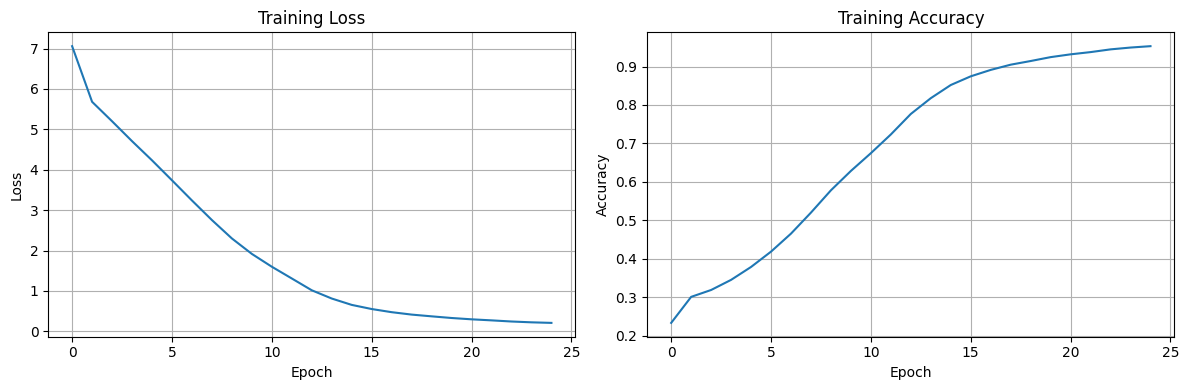

In [35]:
# 학습 결과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# GPU 텐서를 CPU로 옮기고 NumPy 배열로 변환하여 플로팅
acc_cpu = [a.cpu().numpy() for a in history['acc']]
ax2.plot(acc_cpu)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Step 5. 모델 평가하기
---
입력된 문장에 대해서 대답을 얻는 예측 함수를 만듭니다.

In [36]:
# 추론 함수
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    sentence = preprocess_sentence(sentence)
    enc_input_ids = [tokenizer.bos_id()] + tokenizer.encode(sentence) + [tokenizer.eos_id()]
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    dec_input = torch.tensor([[tokenizer.bos_id()]], dtype=torch.long, device=device)

    for i in range(MAX_LENGTH):
        predictions = model(enc_input, dec_input)
        predicted_id = torch.argmax(predictions[:, -1:, :], dim=-1)

        if predicted_id.item() == tokenizer.eos_id():
            break

        dec_input = torch.cat([dec_input, predicted_id], dim=-1)

    return dec_input.squeeze().tolist()

In [37]:
# 문장 생성 함수
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    model.eval()
    output_seq = decoder_inference(model, sentence, tokenizer, device)
    predicted_sentence = tokenizer.decode(
        [t for t in output_seq if t != tokenizer.bos_id() and t != tokenizer.eos_id() and t != tokenizer.pad_id()]
    )
    print('입력 :', sentence)
    print('출력 :', predicted_sentence)
    return predicted_sentence

In [41]:
# 챗봇 테스트
sentence = '안녕?'
sentence_generation(model, sentence, sp, device)

입력 : 안녕?
출력 : 안녕하세요 .


'안녕하세요 .'

In [39]:
sentence = '오늘 기분이 좋아'
sentence_generation(model, sentence, sp, device)

입력 : 오늘 기분이 좋아
출력 : 저도 좋아요 .


'저도 좋아요 .'

In [40]:
sentence = '바보야'
sentence_generation(model, sentence, sp, device)

입력 : 바보야
출력 : 바보를 사랑하는 사람이 있을 거예요 .


'바보를 사랑하는 사람이 있을 거예요 .'

In [43]:
while True:
    user_input = input('입력 문장: ')
    if user_input.lower() == '종료':
        print('챗봇 테스트를 종료합니다.')
        break
    sentence_generation(model, user_input, sp, device)

입력 문장: 종 료
입력 : 종 료
출력 : 축하드려요 .
입력 문장: 종료
챗봇 테스트를 종료합니다.
